# 1. Import Dependencies and Setup

In [14]:
#pip install protobuf==3.20.*

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import cv2
import imghdr
from matplotlib import pyplot as plt
from tensorflow.keras import models, layers, metrics
from tensorflow.keras.metrics import Precision, Recall, AUC

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
for gpu in tf.config.experimental.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

Num GPUs Available:  0


# 2. Preprocess Data

In [5]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']
for image_class in os.listdir(os.path.join('data')):
    for image in os.listdir(os.path.join('data', image_class)):
        image_path = os.path.join('data', image_class, image)
        try:
            img = cv2.imread(image_path)
            typ = imghdr.what(image_path)
            if typ not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            print(e)
            # os.remove(image_path)
print('Complete!')

Issue with image data\chicken\.ipynb_checkpoints
[Errno 13] Permission denied: 'data\\chicken\\.ipynb_checkpoints'
Issue with image data\steak\.ipynb_checkpoints
[Errno 13] Permission denied: 'data\\steak\\.ipynb_checkpoints'
Complete!


# 3. Load and Scale Data

Found 3826 files belonging to 5 classes.
['chicken', 'pasta', 'salad', 'steak', 'sushi']


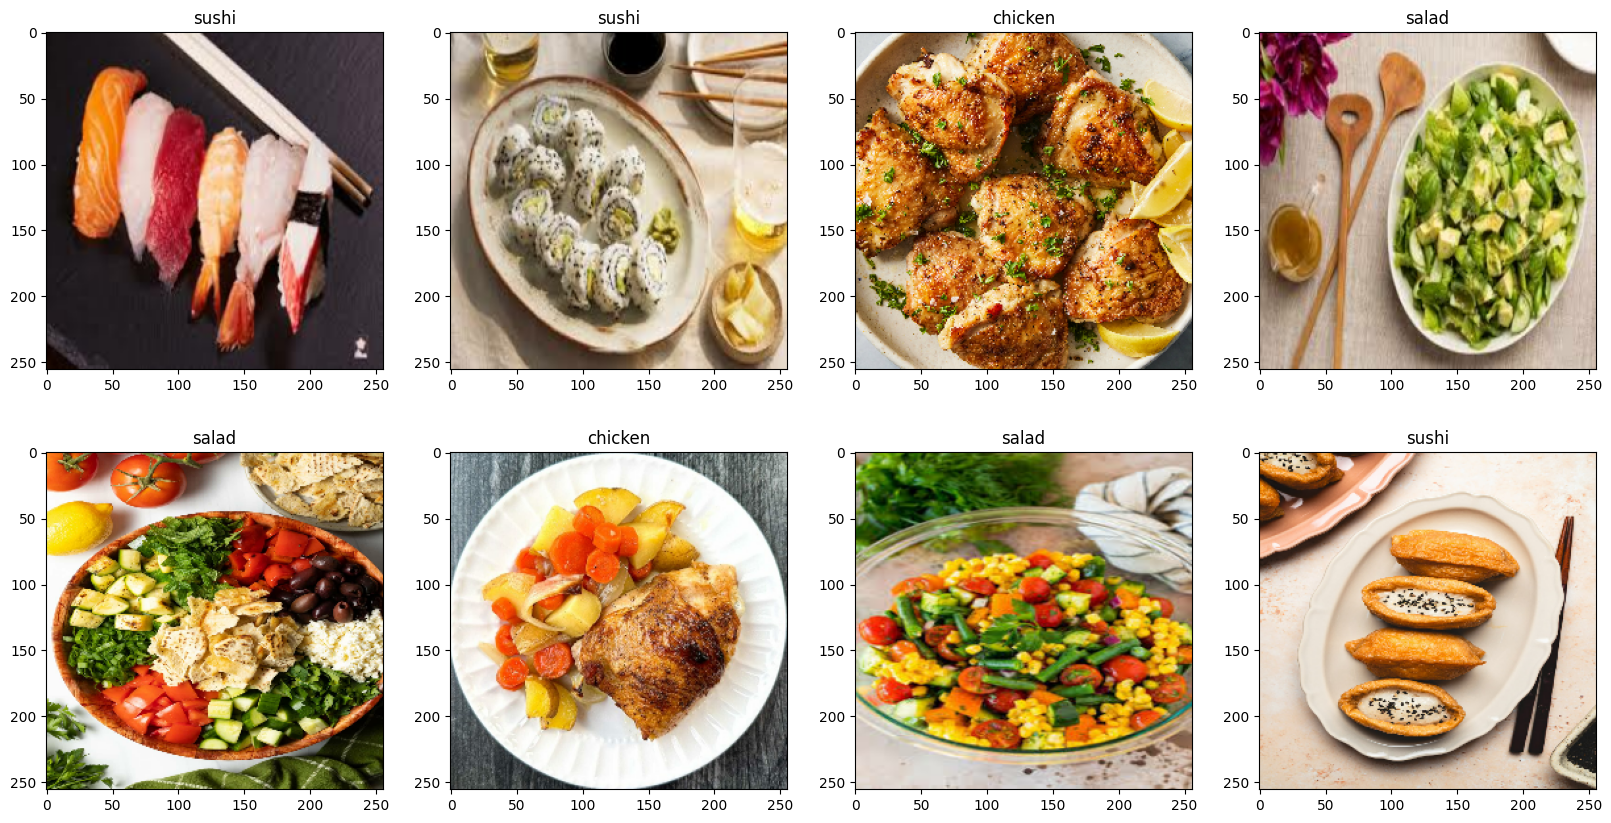

In [6]:
data = tf.keras.utils.image_dataset_from_directory('data', seed=1)
iter = data.as_numpy_iterator()
# batch object has the image at batch[0] in numpy RGB array form, and the corresponding label at batch[1]
batch = iter.next()
labels =  os.listdir('data')
print(labels)

# visualization
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(20,10))
for i, img in enumerate(batch[0][:8]):
    ax[i//4][i%4].imshow(img.astype(int))
    ax[i//4][i%4].title.set_text(labels[batch[1][i]])
plt.show()

# scale each RGB value to [0,1]
data = data.map(lambda x,y: (x/255, y))

# 4. Split Data

In [7]:
batch_size = len(data)
train_size = int(batch_size *.7)
val_size = int(batch_size *.2)
test_size = int(batch_size *.1)
while(train_size + val_size + test_size != batch_size):
    test_size += 1
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 5. Train Model

In [8]:
model = models.Sequential() # sequential model that goes layer by layer

model.add(layers.Conv2D(32, (3, 3), 1, activation='relu', input_shape=(256,256,3), padding='same'))
#32 kernels which detects different features, 3x3 kernel window will slide across image, 1 stride (pixel by pixel), RelU after convultion for non-linear patterns, 256x256 height/width, 3 RGB channels, same spatial dimensions in both input and output (padding, no shrinking of image)
model.add(layers.MaxPooling2D())
#downsamples feature maps - reduces spatial dimensions and computation, translation invariance, most important features extracted

model.add(layers.Conv2D(128, (3, 3), 1, activation='relu')) #increase in the number of filters - detect more complex features
model.add(layers.Conv2D(128, (1, 1), 1, activation='relu')) #increase depth without changing spatial dimensions - feature map compression and non-linear transformations.
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(256, (3, 3), 1, activation='relu'))
model.add(layers.Conv2D(256, (1, 1), 1, activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten()) #flattens multidimensional output to 1D vector - fully connected layers expect 1D inputs

model.add(layers.Dense(256, activation='relu')) 
#fully connected layer, 256 neurons - connected to every element in flattened vector, ReLU provides nonlinearity - model can learn complex relationships between features

model.add(layers.Dense(len(labels), activation='softmax'))
#Softmax activation function - converts output to a probability distribution over all classes, each output represents the probability of the input image belonging to each class

In [9]:
model.compile('adam', loss=tf.losses.SparseCategoricalCrossentropy(), metrics=['accuracy']) #defines loss function, the optimizer and the metrics
#compile our model together using momentum, learning rates, targets, and accuracy
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 128)     36992     
                                                                 
 conv2d_2 (Conv2D)           (None, 126, 126, 128)     16512     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 63, 63, 128)      0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 256)       2

In [10]:
cb = tf.keras.callbacks.TensorBoard(log_dir='logs') #visualizing training process
hist = model.fit(train, epochs=5, validation_data=val, callbacks=cb) #training data

Epoch 1/5
84/84 [==============================] - 587s 7s/step - loss: 1.6930 - accuracy: 0.3151 - val_loss: 1.3182 - val_accuracy: 0.4479
Epoch 2/5
84/84 [==============================] - 710s 8s/step - loss: 1.0580 - accuracy: 0.5818 - val_loss: 0.8528 - val_accuracy: 0.6693
Epoch 3/5
84/84 [==============================] - 698s 8s/step - loss: 0.7691 - accuracy: 0.7132 - val_loss: 0.8078 - val_accuracy: 0.6836
Epoch 4/5
84/84 [==============================] - 740s 9s/step - loss: 0.6051 - accuracy: 0.7682 - val_loss: 0.8167 - val_accuracy: 0.6927
Epoch 5/5
84/84 [==============================] - 714s 8s/step - loss: 0.4568 - accuracy: 0.8333 - val_loss: 0.7801 - val_accuracy: 0.7513


In [11]:
model.save(os.path.join('models', 'model_v4.h5')) #save model if desired

# Visualizations!!!

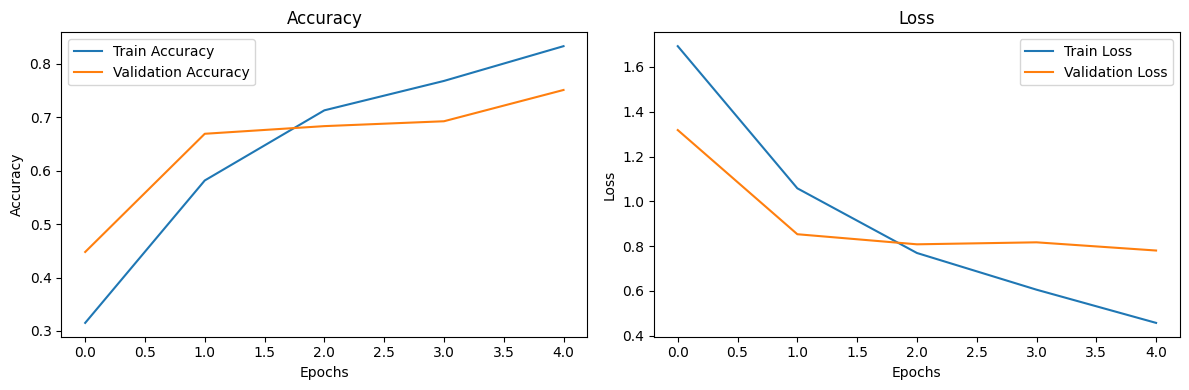

In [12]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(hist)

12/12 [==============================] - 22s 2s/step


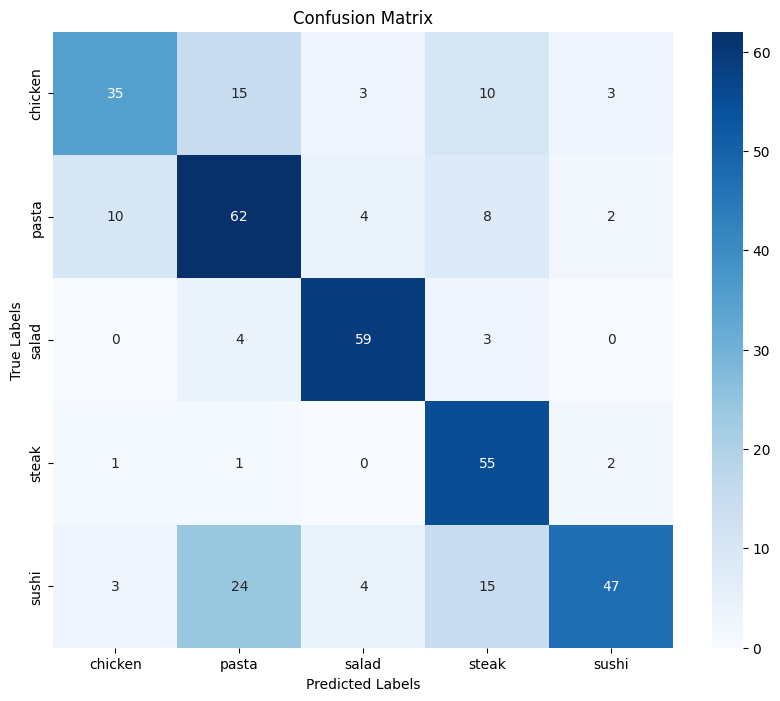

Classification Report:
               precision    recall  f1-score   support

     chicken       0.71      0.53      0.61        66
       pasta       0.58      0.72      0.65        86
       salad       0.84      0.89      0.87        66
       steak       0.60      0.93      0.73        59
       sushi       0.87      0.51      0.64        93

    accuracy                           0.70       370
   macro avg       0.72      0.72      0.70       370
weighted avg       0.73      0.70      0.69       370



In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report
test_images = []
test_labels = []

for batch in test.as_numpy_iterator():
    X, y = batch
    test_images.append(X)
    test_labels.append(y)

# Convert list to numpy arrays
test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert softmax outputs to class labels

# Generate confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(test_labels, y_pred_classes, target_names=labels))

In [14]:
# Create a compact truth table of actual vs predicted
truth_table = pd.DataFrame({
    'Actual': [labels[true] for true in test_labels],
    'Predicted': [labels[pred] for pred in y_pred_classes]
})

# Show first few entries
print(truth_table.head(50))

     Actual Predicted
0     pasta     pasta
1     pasta     pasta
2   chicken     pasta
3     sushi     pasta
4   chicken   chicken
5     pasta     sushi
6     steak     steak
7   chicken   chicken
8     sushi     steak
9     salad     salad
10    sushi     steak
11    salad     salad
12    sushi     pasta
13    pasta     pasta
14    pasta     pasta
15    pasta     pasta
16    steak     steak
17    sushi     sushi
18    sushi     salad
19    sushi   chicken
20    sushi     steak
21    sushi     sushi
22    salad     salad
23    sushi     pasta
24    pasta     salad
25    steak     steak
26    steak     steak
27    pasta     pasta
28  chicken   chicken
29    sushi     pasta
30    sushi     sushi
31    salad     salad
32    steak     steak
33    pasta     pasta
34    steak     steak
35    steak     steak
36    pasta     pasta
37    sushi     sushi
38    pasta   chicken
39    steak     steak
40    sushi     sushi
41    sushi     sushi
42    steak     steak
43    salad     salad
44    past

# 6. Testing

1/1 [==============================] - 1s 848ms/step
Accuracy is : 0.8567567567567568


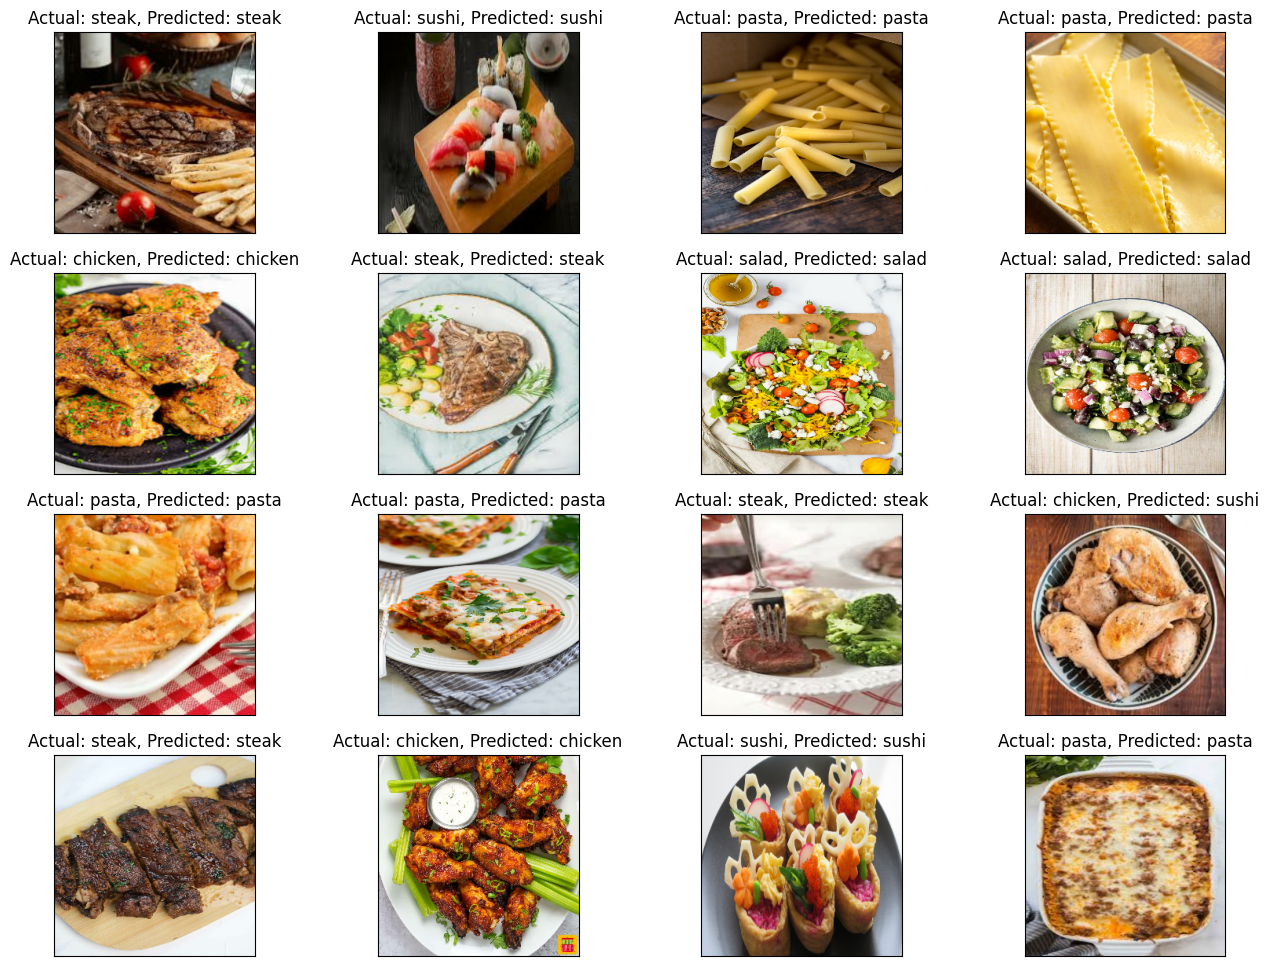

In [17]:
#model = models.load_model(os.path.join('models', 'model_87.h5'))

fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(16,12))

df = pd.DataFrame()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    num_images = min(16, X.shape[0])  # Ensure we don't exceed available images
    for i in range(num_images):
        ax[i//4][i%4].imshow(X[i])
        ax[i//4][i%4].title.set_text('Actual: ' + labels[y[i]] + ', Predicted: ' + labels[np.argmax(yhat[i])])
        ax[i//4][i%4].get_xaxis().set_ticks([])
        ax[i//4][i%4].get_yaxis().set_ticks([])
    
    temp = pd.DataFrame({'actual' : y.tolist(), 'prediction' : yhat.tolist()})
    temp['prediction'] = temp['prediction'].apply(np.argmax)
    
    df = pd.concat([df, temp], axis=0)
true_count = df[df.actual == df.prediction].shape[0]
acc = true_count / df.shape[0]
print('Accuracy is :', acc)

In [ ]:
print('complete!')